# 變異prompt
設定初始的prompt 判斷漲跌並計算其準確率和期望值  
再拿最高的年化報酬率的prompt變異

使用期交所的歷史台指期資料  
存入的檔案日期當天的，漲跌是由前一天的新聞判斷  
存在 out mutate 2  
compare old prompt 比較舊版的prompt  
thought mutate 用比較長的prompt搭月是六個步驟判斷 判斷分成 yes no unknown  
running: 判斷只有 yes no  





In [3]:
# %pip install langchain_google_genai
# %pip install mplfinance
# %pip install google-generativeai

# 測試用
# res = [AIMessage(content='#unknown \n', response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-04d0f448-5551-49df-b0d6-8d2a91183126-0', usage_metadata={'input_tokens': 2448, 'output_tokens': 2, 'total_tokens': 2450}), AIMessage(content='#unknown \n', response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-5a3e9d36-0360-4594-9633-f06f65c2436f-0', usage_metadata={'input_tokens': 2481, 'output_tokens': 2, 'total_tokens': 2483}), AIMessage(content='#unknown \n', response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-101ecc58-3ad1-4000-8d0d-a3b0f32fec9f-0', usage_metadata={'input_tokens': 2783, 'output_tokens': 2, 'total_tokens': 2785}), AIMessage(content='請提供股票代號或公司名稱，以便判斷明天開盤時買進收盤時賣出的獲利可能性。', response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-ca01381d-1726-4a08-ae4b-94f7efadc64c-0', usage_metadata={'input_tokens': 2682, 'output_tokens': 26, 'total_tokens': 2708}), AIMessage(content='#unknown \n', response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-39629b1f-d3c4-439f-ab76-d8408ef0b236-0', usage_metadata={'input_tokens': 2554, 'output_tokens': 2, 'total_tokens': 2556}), AIMessage(content='#unknown \n', response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-5e35913b-f089-4f73-a932-3d6eb06ad91e-0', usage_metadata={'input_tokens': 2595, 'output_tokens': 2, 'total_tokens': 2597}), AIMessage(content='#unknown \n', response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-d7eaf32d-3a68-4bbb-b500-408551a11ad9-0', usage_metadata={'input_tokens': 2233, 'output_tokens': 2, 'total_tokens': 2235}), AIMessage(content='#unknown \n', response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-82bc741e-5ff9-42f6-912a-73d762849e04-0', usage_metadata={'input_tokens': 2469, 'output_tokens': 2, 'total_tokens': 2471}), AIMessage(content='#unknown \n', response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-136cb469-9225-4f45-9830-927e6c22f3cc-0', usage_metadata={'input_tokens': 2448, 'output_tokens': 2, 'total_tokens': 2450}), AIMessage(content='#unknown \n', response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-0bce1e37-fd26-4bac-a1bf-79b467df10cb-0', usage_metadata={'input_tokens': 2352, 'output_tokens': 2, 'total_tokens': 2354}), AIMessage(content='#unknown \n', response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-05669d1e-b852-4a3d-ba19-b6f27244974a-0', usage_metadata={'input_tokens': 3072, 'output_tokens': 2, 'total_tokens': 3074}), AIMessage(content='#unknown \n', response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-bda1264b-fed1-47b0-8244-b9231cf1d57b-0', usage_metadata={'input_tokens': 2890, 'output_tokens': 2, 'total_tokens': 2892}), AIMessage(content='#unknown \n', response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-eec9a31d-3575-42aa-9ffa-df7b788b019c-0', usage_metadata={'input_tokens': 3089, 'output_tokens': 2, 'total_tokens': 3091}), AIMessage(content='#unknown \n', response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-3593848b-6f2e-496a-9f4f-e86a943b9364-0', usage_metadata={'input_tokens': 3267, 'output_tokens': 2, 'total_tokens': 3269}), AIMessage(content='請提供股票代號，以便我根據新聞標題判斷明日開盤買進收盤賣出是否能獲利。\n', response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-e8c78b2a-1d03-4608-8d0a-5f79122083fa-0', usage_metadata={'input_tokens': 3153, 'output_tokens': 27, 'total_tokens': 3180})]
        # print(res)

# full_stack 的prompt  
# prompt_stack = [('\n對業務創新倡議進行徹底分析，審查其對預期目標群體的潛在影響。仔細評估投資者對未來成長的看法，這些看法將提供持續股價增長的理由，並找出支撐這種樂觀態度的關鍵因素。\n', 0), ('企業創新策略的深入探討：從目標客戶群體的影響到投資者預期與股價增長 \n', 0.3333333333333333), ('## 企業創新策略：深挖潛力與投資展望\n\n本文將深入探討企業創新策略，分析其對目標客戶群體的潛在影響，並探究投資者對未來發展的預期。文章將重點分析這些預期如何促進股價持續增長，並揭示驅動增長的關鍵因素。 \n', 0.36363636363636365), ('##  創新引擎：如何助力企業實現客戶、投資者和股價的三重奏勝利\n\n本文將深入探討企業創新策略，分析其如何滿足客戶需求，吸引投資者關注，並進一步探究如何通過這些因素促進股價持續增長。文章將重點分析創新策略的驅動力，以及其如何塑造企業未來發展方向。 \n', 0.36363636363636365), ('## 驅動增長：解鎖創新策略的潛力，贏得客戶、投資者和股價的青睞\n\n本文將深入分析企業創新策略，探討其如何有效地滿足客戶需求，吸引投資者的目光，並最終實現股價持續增長。我們將重點分析驅動創新策略的核心因素，以及其如何為企業塑造一個充滿活力的未來。 \n', 0.375), ('## 企業創新策略：深入探討其對客戶、投資者與股價的影響\n\n本文將深入探討企業創新策略，並分析其對目標客戶群體的潛在影響、投資者對未來發展的預期，以及這些預期如何促進股價持續增長，並探究其背後的主要驅動力。 \n', 0.391304347826087), ('## 企業創新：解鎖客戶、投資者和股價的三重增長引擎\n\n本文將深入探討企業創新策略，分析其如何通過滿足客戶需求、吸引投資者興趣和推動股價增長，實現企業可持續發展。 \n', 0.4117647058823529), ('## 企業創新策略：客戶、投資者與股價的影響\n\n本文將深入探討企業創新策略，分析其對客戶、投資者和股價的影響。我們將探究企業如何利用創新策略滿足客戶需求，以及投資者如何解讀這些策略，並將其轉化為對未來發展的預期。進一步地，我們將分析這些預期如何影響股價的持續增長，並探討其背後的主要驅動力。\n', 0.4166666666666667), ('##  創新引擎：驅動客戶、投資者和股價的三重奏\n\n本文將深入解析企業如何通過創新策略，滿足客戶需求，吸引投資者目光，並最終實現股價持續攀升。我們將探究創新的核心驅動力，以及它如何塑造企業的未來發展方向，成就企業的輝煌。 \n', 0.4375), ('## 創新驅動：如何實現企業、客戶、投資者與股價的四重奏勝利\n\n本文將深入探討企業如何通過創新策略，達成客戶滿意、投資者青睞、股價上漲的「四重奏」目標。我們將分析創新驅動力的核心因素，並探討其如何塑造企業的未來發展方向。 \n', 0.45), ('## 驅動增長：企業創新策略的制勝之道\n\n本文將深入探討企業如何利用創新策略，贏得客戶青睞，吸引投資者目光，並最終實現股價的持續增長。我們將分析創新策略背後的驅動力，以及其如何塑造企業的未來發展方向。 \n', 0.45454545454545453), ('深入評估企業創新方案，分析其對目標受眾的潛在影響，探討投資者對未來增長的預期，並闡明這些預期如何推動股價持續增長及其背後的關鍵驅動力。 \n', 0.4666666666666667), ('深入探討商業創新計劃，評估其對目標客戶群的潛在影響，分析投資者對未來增長的期望，並探究這些期望如何推動持續股價增長及其關鍵驅動因素。 \n', 0.4666666666666667), ('## 創新引擎：引領企業邁向客戶、投資者和股價的三重奏勝利\n\n本文將深入探討企業如何運用創新策略，打造滿足客戶需求的產品和服務，吸引投資者目光，並最終推動股價持續攀升，實現企業、客戶、投資者三方共贏的局面。文章將重點分析創新策略的核心驅動力，以及其如何引領企業走向更輝煌的未來。 \n', 0.47058823529411764), ('## 驅動增長：企業創新戰略的成功秘訣\n\n本文將深入探討企業如何通過創新戰略來贏得客戶、吸引投資者和推動股價上漲。我們將分析創新戰略的關鍵驅動力，以及如何利用創新來塑造企業的未來發展。 \n', 0.47058823529411764), ('深入分析業務創新倡議，評估其對目標受眾的潛在影響，並探討投資者對未來增長的預期。分析這些預期如何支撐持續股價增長，並探討其背後的關鍵因素，包括市場需求、競爭格局、技術進步、營運效率和財務績效。 \n', 0.47619047619047616), ('## 企業創新策略：深入探討其對客戶、投資者和股價的影響\n\n**一、創新策略的潛在客戶影響**\n\n* **提升客戶體驗:** 透過創新，企業能提供更優質、更個人化的產品和服務，滿足客戶的需求並創造更高的客戶滿意度。\n* **擴大市場份額:** 獨特創新能吸引新客戶群體，擴大市場份額並提高市場競爭力。\n* **提高品牌忠誠度:**  持續創新能強化品牌形象，建立客戶信任，並促進品牌忠誠度。\n\n**二、投資者對未來發展的預期**\n\n* **盈利能力提升:** 創新產品和服務的成功推出，預計將帶來更高的盈利能力和營收增長。\n* **市場領導地位:**  持續創新能鞏固企業在市場上的領導地位，提升市場份額和競爭優勢。\n* **長期投資價值:**  創新能力是企業長期發展的核心，投資者預期企業將持續創造價值，並獲得長期投資回報。\n\n**三、促進股價持續增長的主要驅動力**\n\n* **盈利預期提升:**  創新帶來的盈利能力提升，將直接推動股價上漲。\n* **市場份額擴大:**  隨著市場份額的擴大，企業的價值和盈利潛力將得到提升，進而推動股價上漲。\n* **投資者信心增加:**  創新能力的提升，將提高投資者對企業未來發展的信心，促進股價上漲。\n* **品牌價值提升:**  創新推動品牌價值提升，吸引更多投資者，進而推動股價上漲。\n\n**結論**\n\n企業創新策略是企業持續發展的核心，能為客戶帶來更好的體驗，為投資者創造更高的投資回報。創新帶來的盈利能力提升、市場份額擴大、投資者信心增加和品牌價值提升，都將成為推動股價持續增長的主要驅動力。\n', 0.4782608695652174), ('## 業務創新倡議分析：影響、投資者預期與股價增長\n\n**一、深入分析業務創新倡議**\n\n* 詳細說明創新內容，包括目標、方法、技術應用等。\n* 分析創新對現有業務模式的影響，以及潛在的市場機會和挑戰。\n* 評估創新實現的難度，以及所需的資源投入。\n\n**二、評估創新對目標受眾的潛在影響**\n\n* 識別目標受眾群體，包括客戶、員工、合作夥伴等。\n* 分析創新對各個受眾群體的正面和負面影響，例如提高用戶體驗、增加收入、提升工作效率等。\n* 評估受眾對創新的接受程度，以及可能產生的反饋。\n\n**三、考察投資者對未來增長的預期**\n\n* 分析投資者對創新項目的評價，包括其預期帶來的盈利增長、市場佔有率提升等。\n* 調查投資者對創新風險的評估，以及其對投資回報的期望。\n* 分析投資者對公司未來發展的信心，以及對股價的預期。\n\n**四、探討投資者預期與股價增長之間的關係**\n\n* 分析投資者預期如何影響公司市值和股價表現。\n* 考察哪些關鍵因素會影響投資者對股價的信心，例如盈利能力、市場競爭力、管理團隊表現等。\n* 探討公司如何通過有效溝通和策略管理，將投資者預期轉化為持續的股價增長。\n\n**五、總結與建議**\n\n* 總結分析結果，並提出對公司創新倡議的評價和建議。\n* 指出公司應如何優化創新策略，以最大程度地實現投資者預期和股價增長。\n', 0.4827586206896552), ('深入評估業務創新倡議，分析其對目標受眾的影響，並探討投資者對未來增長的預期，同時探究這些預期如何支撐持續股價增長及其背後的關鍵因素。 \n', 0.5), ('## 企業創新策略：驅動客戶、投資者和股價的引擎\n\n本文將深入探討企業如何利用創新策略，滿足客戶需求、吸引投資者，並最終推動股價持續增長。文章將分析創新策略的驅動力，以及其如何塑造企業的未來發展方向。 \n', 0.5), ('## 突破界限，贏得三方認可：企業創新策略的雙贏之路\n\n本文將深入探討企業如何通過創新策略，實現客戶滿意、投資者青睞和股價攀升的雙贏局面。文章將分析創新策略的核心驅動力，以及其如何塑造企業的未來發展方向，並重點探討如何將創新轉化為可持續的商業成功。 \n', 0.5), ('## 企業創新策略：顧客、投資者與股價的連結\n\n本文將深入探討企業創新策略，分析其如何影響目標客戶群體、投資者的預期，以及這些預期如何驅動股價的持續增長。 我們將深入研究這些關鍵因素之間的聯繫，並探討其背後的核心驅動力。 \n', 0.5151515151515151), ('深入分析業務創新倡議，評估其對目標受眾的潛在影響，並考察投資者對未來增長的預期。分析這些預期如何支撐持續股價增長，並探討其背後的關鍵因素。 \n', 0.5238095238095238), ('深入分析業務創新倡議，評估其對目標受眾的潛在影響，考察投資者對未來增長的預期，並探討這些預期如何支撐持續股價增長及其背後的關鍵因素。 \n', 0.5263157894736842), ('## 企業創新：驅動客戶、投資者與股價的共贏\n\n本文將深入探討企業創新策略，分析其如何滿足客戶需求，吸引投資者目光，並進一步探究如何通過這些因素促進股價持續增長。文章將重點分析創新策略的驅動力，以及其如何塑造企業的未來發展方向。 \n', 0.5348837209302325), ('## 創新引擎：驅動企業增長，贏得三方認可\n\n本文將深入探討創新如何成為企業的制勝策略，滿足客戶需求，吸引投資者目光，並最終實現股價持續攀升。我們將解析創新的核心驅動力，以及它如何塑造企業的未來發展方向，引領企業邁向成功。 \n', 0.5384615384615384), ('深入探討企業創新策略，評估其對目標客戶群體的潛在影響，分析投資者對未來發展的預期，並探究這些預期如何促進股價持續增長及其背後的主要驅動力。 \n', 0.5454545454545454), ('## 企業創新策略的深入探討：影響、預期和股價增長\n\n本文深入探討企業創新策略，分析其對目標客戶群體的潛在影響，以及投資者對未來發展的預期。更重要的是，我們將探討這些預期如何促進股價持續增長，並揭示其背後的主要驅動力。 \n', 0.5454545454545454), ('## 創新驅動：贏得客戶、投資者與股價的三重奏\n\n本文將深入探討企業如何運用創新策略，達成客戶滿意、吸引投資者目光，並最終實現股價持續增長的目標。文章將重點分析創新策略的關鍵要素，以及其如何塑造企業的未來發展方向，引領企業邁向雙贏甚至三贏的局面。 \n', 0.56), ('## 驅動成長：如何利用企業創新策略贏得客戶、投資者和股價的青睞\n\n本文將深入探討企業創新策略如何成為企業成長的關鍵引擎，分析其如何滿足客戶需求、吸引投資者目光，並最終推動股價持續上漲。文章將重點探討創新策略的驅動力，以及其如何塑造企業的未來發展方向。 \n', 0.56), ('## 創新引擎：驅動企業成長的關鍵策略\n\n本文將深入探討企業如何運用創新策略，滿足客戶需求，吸引投資者青睞，並最終實現股價的持續攀升。我們將分析創新背後的驅動力，以及它如何塑造企業的未來發展方向，成為企業永續成長的引擎。 \n', 0.5652173913043478), ('## 企業創新：釋放客戶、投資者和股價的成長潛力\n\n本文將深入探討企業創新策略，分析其如何吸引目標客戶群體，獲得投資者青睞，並進一步探究這些因素如何推動股價持續增長。 \n', 0.5675675675675675), ('## 企業創新：激發客戶、投資者和股價的持續增長\n\n本文將深入探討企業創新策略，分析其如何滿足目標客戶的需求，吸引投資者的目光，並進一步探究這些因素如何推動股價的持續增長。 \n', 0.5681818181818182), ('**創新：企業增長的引擎，贏得客戶、投資者和股價的關鍵**\n\n本文將探討企業如何運用創新策略，滿足客戶需求，吸引投資者青睞，並最終實現股價持續攀升。我們將深入分析創新背後的驅動力，以及它如何塑造企業的未來發展方向。 \n', 0.5714285714285714), ('企業創新：解鎖客戶、投資者和股價的三重成長引擎 \n', 0.575), ('## 驅動企業成長：創新策略引領客戶、投資者與股價共舞\n\n本文將深入探討企業創新策略，闡述其如何滿足客戶需求、吸引投資者目光，並進一步探討這些因素如何促進股價持續增長。文章將重點分析創新策略的驅動力，以及其如何塑造企業未來發展方向，並為企業領導者提供實用策略。 \n', 0.575), ('## 驅動增長：企業創新策略如何成為贏得客戶、投資者和股價青睞的關鍵\n\n本文將深入探討企業創新策略，分析其如何有效滿足客戶需求，吸引投資者關注，並最終推動股價持續增長。文章將重點分析創新策略的驅動力，以及其如何塑造企業的未來發展方向，引領企業邁向成功。 \n', 0.5789473684210527), ('**企業創新：開啟客戶、投資者和股價的增長之路**\n\n本文將深入探討企業創新策略，分析其如何吸引目標客戶群體，吸引投資者關注，並進一步探究這些因素如何推動股價持續增長。 \n', 0.5873015873015873), ('企業創新策略的深入探討，包括其對目標客戶群體的潛在影響，投資者對未來發展的預期，以及這些預期如何促進股價持續增長及其背後的主要驅動力。 \n', 0.59375), ('## 企業創新策略：深入探討其對客戶、投資者和股價的影響\n\n本文將深入探討企業創新策略，分析其對目標客戶群體的潛在影響，以及投資者對未來發展的預期，並進一步探究這些預期如何促進股價持續增長，以及其背後的主要驅動力。 \n', 0.6), ('## 創新引擎：驅動客戶、投資者和股價的增長秘訣\n\n本文將探討企業如何通過創新策略，滿足客戶需求，贏得投資者的青睞，並最終實現股價的持續攀升。我們將深入分析創新的核心驅動力，以及它如何塑造企業的未來發展軌跡。 \n', 0.6), ('## 驅動增長：企業創新策略如何贏得客戶、投資者和股價的青睞\n\n本文將深入探討企業創新策略，分析其如何滿足客戶需求，吸引投資者的關注，並最終促進股價持續增長。文章將重點分析創新策略的驅動力，以及其如何塑造企業的未來發展方向。 \n', 0.6086956521739131)]

# full_cot
# prompt_stack = [('## 企業創新策略的成功三要素：協同作用成就可持續優勢\n\n企業創新策略的成功，並非單一要素的結果，而是需要以下三項關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新必須以客戶為中心，深入理解客戶需求，並提供獨特的價值主張。 滿足客戶需求、解決客戶問題，才能吸引客戶，建立品牌忠誠度，從而帶來持續的市場需求和盈利能力，最終實現企業的可持續發展。\n\n**2. 商業可持續性：** 創新必須建立在可持續的商業模式之上，確保長期盈利能力和增長潛力。 穩定的盈利能力是吸引投資者注資的關鍵，而增長潛力則確保創新成果能夠持續發展。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。\n\n三者相互交織，缺一不可。 唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。\n', 0.6), ('企業創新策略要成功，必須同時滿足三項關鍵要素：\n\n1. **滿足客戶需求：** 產品或服務必須能有效解決客戶問題或滿足其需求，並提供獨特價值。\n2. **吸引投資者興趣：** 創新必須具有可持續的商業模式，能吸引投資者注資並為企業帶來長期價值。\n3. **推動股價上漲：** 創新必須能提升企業的盈利能力和市場競爭力，進而帶動股價的持續增長。\n\n只有滿足以上三項要素，企業創新策略才能取得成功，並為企業帶來可持續的發展。\n', 0.6071428571428571), ('## 企業創新策略的成功三要素：協同奏效，成就可持續優勢\n\n企業創新策略的成功，並非單一要素的成就，而是以下三項關鍵要素協同作用的結果：\n\n**1. 以客戶為中心：** 成功的創新必須從客戶需求出發，解決客戶問題，創造獨特的價值主張。 只有真正滿足客戶需求，才能吸引客戶，建立品牌忠誠度，帶來持續的市場需求和盈利能力，實現可持續發展。\n\n**2. 商業可持續性：** 創新需要建立在可持續的商業模式之上，才能吸引投資者和合作伙伴的持續支持。 穩定的盈利能力和增長潛力是吸引投資者注資的關鍵，也是確保創新成果能夠持續發展的保障。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。 \n\n只有將這三項要素緊密結合，形成協同作用，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.6086956521739131), ('## 企業創新策略的成功三要素：協同作用下的持久競爭力\n\n企業創新策略的成功，並非單一要素的輝煌，而是三項關鍵要素協同作用下的必然結果。 \n\n**1. 以客戶為中心：** 成功的創新始終以解決客戶問題、滿足客戶需求為核心。 透過提供獨特的價值主張，贏得客戶的認可和持續付費，不僅創造市場需求，更建立品牌忠誠度，為企業帶來持續的盈利能力。\n\n**2. 投資吸引力：**  創新需要建立在可持續的商業模式之上，吸引投資者的注資，為企業帶來長期的價值，例如穩定的盈利能力和增長潛力。 只有投資者相信創新能帶來回報，才能持續支持企業發展，推動其邁向成功。\n\n**3. 市場競爭力：** 創新應能提升企業的盈利能力和市場競爭力，進而帶動股價持續增長，在市場中建立領先地位。 唯有保持競爭力，企業才能在市場上立足，並持續發展，獲得長久的成功。\n\n只有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.6153846153846154), ('## 企業創新策略的成功三要素：以客戶為中心，商業可持續，競爭力領先\n\n企業創新策略的成功，並非單一要素的結果，而是需要以下三項關鍵要素的協同共生，缺一不可：\n\n**1. 以客戶為中心：**  創新需要以深刻理解客戶需求為起點，為其提供獨特的價值主張。唯有滿足客戶需求，解決客戶問題，才能吸引客戶，建立品牌忠誠度，進而帶來持續的市場需求和盈利能力，最終實現企業的可持續發展。\n\n**2. 商業可持續性：**  創新需要建立在可持續的商業模式之上，確保其長期盈利能力和增長潛力。穩定的盈利能力是吸引投資者注資的關鍵，而增長潛力則是確保創新成果能夠持續發展的保障。 \n\n**3. 市場競爭力：**  成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。只有保持競爭力，企業才能在市場上立足，並持續發展。 \n\n這三者相互交織，缺一不可。唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.6153846153846154), ('企業創新策略的成功，需要三項關鍵要素的協同作用：\n\n1. **客戶導向：** 創新產品或服務必須能有效解決客戶問題，滿足其需求，並提供獨特價值，讓客戶願意為其付費。\n2. **投資吸引力：** 創新必須具有可持續的商業模式，能吸引投資者注資，並為企業帶來長期價值，例如穩定的盈利能力和增長潛力。\n3. **市場競爭力：** 創新必須能提升企業的盈利能力和市場競爭力，進而帶動股價的持續增長，在市場中建立領先地位。\n\n只有同時滿足這三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展。 \n', 0.6206896551724138), ('## 企業創新策略的成功三要素：協同作用成就可持續優勢\n\n企業創新策略要取得成功，必須具備以下三項關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新必須以解決客戶問題、滿足客戶需求為核心，創造獨特的價值主張，才能吸引客戶，建立品牌忠誠度，並帶來持續的市場需求和盈利能力。\n\n**2. 商業模式的可持續性：** 創新需要建立在可持續的商業模式之上，才能吸引投資者注資，為企業帶來長期的價值，例如穩定的盈利能力和增長潛力。 只有投資者相信創新能帶來回報，才能持續支持企業發展。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，進而帶動股價持續增長，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。\n\n唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.6363636363636364), ('## 企業創新策略的成功三要素：協同作用成就可持續優勢\n\n企業創新策略的成功，需要三項關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新必須從客戶需求出發，以解決客戶問題為核心。 只有提供獨特的價值主張，滿足客戶未被滿足的需求，才能吸引客戶，建立品牌忠誠度，並帶來持續的市場需求和盈利能力。\n\n**2. 商業模式可持續性：** 創新需要建立在可持續的商業模式之上，才能吸引投資者的注資，並為企業帶來長期的價值，例如穩定的盈利能力和增長潛力。 只有投資者相信創新能帶來回報，才能持續支持企業發展。\n\n**3. 競爭優勢：** 成功的創新應能提升企業的盈利能力和市場競爭力，進而帶動股價持續增長，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。\n\n只有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.6363636363636364), ('##  企業創新策略的三大支柱：協同共築可持續優勢\n\n企業創新策略要取得成功，需要三項關鍵要素的協同作用，缺一不可，共同構建企業的可持續發展優勢：\n\n**1. 以客戶為中心：** 成功的創新始終以滿足客戶需求、解決客戶問題為核心，為客戶創造獨特的價值主張。 只有真正了解並滿足客戶需求，才能吸引客戶，建立品牌忠誠度，帶來持續的市場需求和盈利能力，最終實現可持續的發展。\n\n**2. 投資吸引力：** 創新需要建立在可持續的商業模式之上，才能吸引投資者的持續注資。 穩定的盈利能力和增長潛力是吸引投資者的關鍵，讓投資者相信創新能帶來回報，才能為企業提供長期的發展資源，支持企業不斷壯大。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展，獲得長期的成功。\n\n三者相互依存、缺一不可，只有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.64), ('企業創新策略的成功，仰賴三項關鍵要素的協同作用，缺一不可：\n\n**1. 客戶導向：** 創新應以解決客戶問題、滿足客戶需求為核心，並提供獨特的價值主張，讓客戶心甘情願為之付費。 \n\n**2. 投資吸引力：** 創新必須建立在可持續的商業模式之上，吸引投資者注資，並為企業帶來長期的價值，例如穩定的盈利能力和增長潛力。\n\n**3. 市場競爭力：** 創新應能提升企業的盈利能力和市場競爭力，進而帶動股價持續增長，在市場中建立領先地位。\n\n唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展。\n', 0.6451612903225806), ('## 企業創新策略的成功三要素：協同作用成就可持續優勢\n\n企業創新策略的成功，並非單一要素的結果，而是需要以下三項關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新始於深刻理解客戶需求，並提供獨特價值，滿足客戶需求、解決客戶問題，才能建立品牌忠誠度，帶來持續的市場需求和盈利能力，最終實現企業的可持續發展。\n\n**2. 商業可持續性：** 創新需建立在可持續的商業模式之上，確保其長期盈利能力和增長潛力。 穩定的盈利能力吸引投資者注資，增長潛力則確保創新成果持續發展。\n\n**3. 市場競爭力：** 成功的創新應提升企業盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。\n\n三者相互交織，缺一不可。 唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.6470588235294118), ('## 企業創新策略的成功三要素：協同共振，成就可持續優勢\n\n企業創新策略的成功，並非單一要素的結果，而是需要以下三項關鍵要素的協同共振，缺一不可：\n\n**1. 客戶導向：**  成功的創新必須始於對客戶需求的深刻理解，並以提供獨特的價值主張為目標。 唯有滿足客戶需求，解決客戶問題，才能吸引客戶，建立品牌忠誠度，進而帶來持續的市場需求和盈利能力，最終實現企業的可持續發展。\n\n**2. 商業可行性：**  創新需要建立在可持續的商業模式之上，確保其長期盈利能力和增長潛力。 穩定的盈利能力是吸引投資者注資的關鍵，而增長潛力則是確保創新成果能夠持續發展的保障。 \n\n**3. 競爭優勢：**  成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。  只有保持競爭力，企業才能在市場上立足，並持續發展。 \n\n三者相互交織，缺一不可。 唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.6470588235294118), ('## 企業創新策略的成功三要素：協同共贏，成就可持續優勢\n\n企業創新策略的成功，需要三項關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心：** 創新必須以滿足客戶需求、解決客戶問題為核心，創造獨特的價值主張，引發客戶共鳴。 唯有如此，才能建立品牌忠誠度，持續吸引客戶，並帶來可持續的市場需求和盈利能力。\n\n**2. 商業可持續性：** 創新需要建立在穩健的商業模式之上，才能獲得投資者和合作伙伴的持續支持。 穩定的盈利能力和增長潛力是吸引投資的重要因素，也是確保創新成果得以持續發展的關鍵。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 唯有保持競爭力，企業才能在市場上立足，並持續發展，創造可持續的優勢。\n\n三要素相互聯繫，協同作用，才能讓企業創新策略取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.65), ('## 企業創新策略的成功三要素：協同作用成就可持續優勢\n\n企業創新策略的成功，需要以下三項關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新必須以滿足客戶需求、解決客戶問題為核心，為客戶創造獨特的價值主張。 只有這樣，才能吸引客戶，建立品牌忠誠度，帶來持續的市場需求和盈利能力，最終實現可持續發展。\n\n**2. 商業可持續性：** 成功的創新必須建立在可持續的商業模式之上，才能吸引投資者和合作伙伴的持續支持。 穩定的盈利能力和增長潛力是吸引投資者注資的關鍵，也是確保創新成果能夠持續發展的保障。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。 \n\n只有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.65), ('## 企業創新策略的成功三要素：客戶導向、商業可持續性與市場競爭力\n\n企業創新策略的成功，需要三個關鍵要素的相互協同和共振，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新始於深刻理解客戶需求，並提供滿足其需求的獨特價值主張。 唯有真正解決客戶問題，才能建立品牌忠誠度，吸引客戶，創造持續的市場需求和盈利能力，最終實現企業的可持續發展。\n\n**2. 商業可持續性：** 創新必須建立在可持續的商業模式之上，確保其長期盈利能力和增長潛力。 穩定的盈利能力是吸引投資者的關鍵，而增長潛力則能確保創新成果的持續發展，並為企業帶來可持續的發展動力。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，持續發展，並取得長期的成功。\n\n三者相互交織，缺一不可。 唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。\n', 0.65), ('## 企業創新策略的成功三要素：協同作用打造可持續優勢\n\n企業創新策略的成功並非偶然，而是需要三項關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心：** 創新應以解決客戶問題、滿足客戶需求為核心。唯有提供獨特的價值主張，才能吸引客戶，建立品牌忠誠度，進而帶來市場需求和持續的盈利能力。\n\n**2. 商業模式可持續：** 創新需要建立在可持續的商業模式之上，才能吸引投資者，並為企業帶來長期的價值，例如穩定的盈利能力和增長潛力。 只有投資者相信創新能帶來回報，才能持續支持企業發展。\n\n**3. 競爭優勢：** 創新應能提升企業的盈利能力和市場競爭力，進而帶動股價持續增長，在市場中建立領先地位。 唯有保持競爭力，企業才能在市場上立足，並持續發展。\n\n只有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.6521739130434783), ('##  企業創新策略的成功三要素：協同共創可持續優勢\n\n企業創新策略的成功，需要以下三項關鍵要素協同作用，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新必須以滿足客戶需求、解決客戶痛點為核心，為客戶創造獨特的價值主張。 只有這樣，才能吸引客戶，建立品牌忠誠度，帶來持續的市場需求和盈利能力，實現可持續發展。\n\n**2. 投資吸引力：**  創新需要建立在可持續的商業模式之上，才能吸引投資者的注資。 穩定的盈利能力和增長潛力，是吸引投資者持續支持企業發展的關鍵。 投資者相信創新能帶來回報，才能為企業提供長期的發展資源。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。 \n\n只有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.6521739130434783), ('## 企業創新策略的成功三要素：協同作用成就可持續優勢\n\n企業創新策略的成功，並非單一要素的結果，而是需要以下三項關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新始於深刻理解客戶需求，並以其為中心，提供獨特的價值主張。  只有滿足客戶需求，解決客戶問題，才能吸引客戶，建立品牌忠誠度，進而帶來持續的市場需求和盈利能力，最終實現企業的可持續發展。\n\n**2. 商業可持續性：** 創新需要建立在可持續的商業模式之上，確保其長期盈利能力和增長潛力。 穩定的盈利能力是吸引投資者注資的關鍵，而增長潛力則是確保創新成果能夠持續發展的保障。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。\n\n三者相互交織，缺一不可。 唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.6666666666666666), ('## 企業創新策略的成功三要素：以客戶為中心、商業可持續性和市場競爭力\n\n企業創新策略的成功，並非單一要素的結果，而是需要以下三項關鍵要素的協同共振，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新必須始於深刻理解客戶需求，並提供獨特的價值主張。 滿足客戶需求，解決客戶問題，才能吸引客戶，建立品牌忠誠度，進而帶來持續的市場需求和盈利能力，最終實現企業的可持續發展。\n\n**2. 商業可持續性：** 創新必須建立在可持續的商業模式之上，確保其長期盈利能力和增長潛力。 穩定的盈利能力是吸引投資者的關鍵，而增長潛力則能確保創新成果持續發展，創造長期的價值。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展，獲得可持續的優勢。\n\n三者相互交織，缺一不可。 唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。\n', 0.6666666666666666), ('## 企業創新策略的成功三要素：協同作用打造可持續優勢\n\n企業創新策略的成功，並非單一要素所能達成，而是需要三項關鍵要素相互協同、缺一不可：\n\n**1. 以客戶為中心：** 企業的創新必須以滿足客戶需求、解決客戶問題為核心，為客戶創造獨特的價值主張。 只有這樣，才能吸引客戶，建立品牌忠誠度，帶來持續的市場需求和盈利能力，最終實現可持續的發展。\n\n**2. 投資吸引力：** 創新需要建立在可持續的商業模式之上，才能吸引投資者的注資。 穩定的盈利能力和增長潛力，是吸引投資者持續支持企業發展的關鍵。 投資者相信創新能帶來回報，才能為企業提供長期的發展資源。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。 \n\n只有三者相互協同，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.6818181818181818), ('## 企業創新策略的成功三要素：客戶、盈利、競爭\n\n企業創新策略的成功，需要三個關鍵要素的相互協同和共振，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新始於對客戶需求的深刻理解，並提供獨特的價值主張。 滿足客戶需求，解決客戶問題，方能建立品牌忠誠度，吸引客戶，創造持續的市場需求，最終實現企業的可持續發展。\n\n**2. 商業可持續性：** 創新必須建立在可持續的商業模式之上，確保其長期盈利能力和增長潛力。 穩定的盈利能力是吸引投資者的關鍵，而增長潛力則能確保創新成果的持續發展。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。\n\n三者相互交織，缺一不可。 唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。\n', 0.6842105263157895), ('## 企業創新策略的成功三要素：洞悉客戶、可持續盈利、領先競爭\n\n企業創新策略要取得成功，需要三個關鍵要素的緊密結合和協同作用：\n\n**1. 洞悉客戶需求：** 成功的創新始於對客戶需求的深入了解，並提供滿足其需求的獨特價值主張。 只有滿足客戶需求，解決客戶問題，才能建立品牌忠誠度，吸引客戶，創造持續的市場需求和盈利能力，最終實現企業的可持續發展。\n\n**2. 可持續盈利：** 創新必須建立在可持續的商業模式之上，確保其長期盈利能力和增長潛力。 穩定的盈利能力是吸引投資者的關鍵，而增長潛力則能確保創新成果的持續發展。\n\n**3. 領先競爭：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。\n\n三者相互交織，缺一不可。 唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。\n', 0.6842105263157895), ('## 企業創新策略的成功之道：三要素的協同作用\n\n企業創新策略的成功，並非單靠一項要素就能達成，而是需要三項關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心：** 創新必須以解決客戶問題、滿足客戶需求為核心，提供獨特的價值主張，讓客戶心甘情願為之付費。這不僅能帶來市場需求，更能建立品牌忠誠度，為企業創造持續的盈利能力。\n\n**2. 投資吸引力：** 創新需要建立在可持續的商業模式之上，吸引投資者的注資，並為企業帶來長期的價值，例如穩定的盈利能力和增長潛力。 只有投資者相信創新能帶來回報，才能持續支持企業發展。\n\n**3. 市場競爭力：** 創新應能提升企業的盈利能力和市場競爭力，進而帶動股價持續增長，在市場中建立領先地位。 唯有保持競爭力，企業才能在市場上立足，並持續發展。\n\n只有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.6896551724137931), ('## 企業創新策略的三大支柱：協同共創可持續優勢\n\n企業創新策略的成功，並非單一要素的結果，而是建立在三項關鍵支柱的協同作用之上，缺一不可：\n\n**1. 以客戶為核心：** 深入理解客戶需求，提供獨特的價值主張，是創新的基石。滿足客戶需求，解決客戶問題，才能吸引客戶，建立品牌忠誠度，並帶來持續的市場需求和盈利能力，最終實現企業的可持續發展。\n\n**2. 商業模式可持續：** 創新需要建立在可持續的商業模式之上，確保其長期盈利能力和增長潛力。穩定的盈利能力吸引投資者注資，而增長潛力則保證創新成果的持續發展。\n\n**3. 市場競爭優勢：** 成功的創新應提升企業的盈利能力和市場競爭力，在市場中建立領先地位。唯有保持競爭力，企業才能在市場上立足並持續發展。\n\n這三大支柱相互交織，缺一不可。唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續發展，並在市場中取得領先地位。\n', 0.6923076923076923), ('## 企業創新策略的成功三要素：協同作用打造可持續競爭優勢\n\n企業創新策略要取得成功，需要以下三項關鍵要素的協同作用：\n\n**1. 以客戶為中心：** 成功的創新始終以滿足客戶需求、解決客戶問題為核心，為客戶創造獨特的價值主張。 唯有如此，才能吸引客戶，建立品牌忠誠度，進而帶來持續的市場需求和盈利能力，實現可持續發展。\n\n**2. 投資吸引力：** 創新需要建立在可持續的商業模式之上，才能吸引投資者的注資。 穩定的盈利能力和增長潛力是吸引投資者持續支持企業發展的關鍵。 投資者相信創新能帶來回報，才能為企業提供長期的發展資源。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。 \n\n只有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.6956521739130435), ('## 企業創新策略的成功秘訣：協同作用成就可持續優勢\n\n企業創新策略要取得成功，必須建立在以下三項關鍵要素的協同作用之上，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新始於洞悉客戶需求，並以解決客戶問題為目標。 只有為客戶創造獨特的價值主張，才能吸引他們，建立品牌忠誠度，並帶來持續的市場需求和盈利能力，最終實現可持續的發展。\n\n**2. 商業可持續性：** 創新需要建立在穩固的商業模式之上，才能獲得投資者和合作伙伴的持續支持。 穩定的盈利能力和增長潛力是吸引投資的关键，也是確保創新成果能夠持續發展的保障。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力，增强其在市場中的竞争优势，并建立领先地位。 只有保持競爭力，企业才能在市場上立足，並持續發展。 \n\n只有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.7), ('## 企業創新策略的成功三要素：客戶至上、商業可持續、競爭優勢\n\n企業創新策略的成功並非偶然，而是需要三個關鍵要素的協同共生，缺一不可：\n\n**1. 以客戶為中心：** 創新應始於深刻理解客戶需求，並為其提供獨特價值。滿足客戶需求，解決客戶問題，才能建立品牌忠誠度，吸引客戶，最終實現企業的持續發展和盈利。\n\n**2. 商業可持續性：** 創新需要建立在可持續的商業模式之上，確保長期盈利能力和增長潛力。穩定的盈利能力吸引投資者，而增長潛力則保障創新成果的持續發展。\n\n**3. 市場競爭力：** 成功的創新應提升企業盈利能力和市場競爭力，建立領先地位。只有保持競爭力，企業才能在市場中立足並持續發展。\n\n這三要素相互交織，缺一不可。只有同時滿足以上三項要素，企業的創新策略才能取得成功，帶來可持續發展，並在市場中取得領先地位。 \n', 0.7058823529411765), ('## 企業創新策略的成功三要素：客戶導向、商業可持續性和市場競爭力\n\n企業創新策略的成功，並非單一要素的結果，而是需要以下三項關鍵要素的協同共振，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新必須建立在深刻理解客戶需求的基礎上，並為其提供獨特的價值主張。  滿足客戶需求，解決客戶問題，才能吸引客戶，建立品牌忠誠度，進而帶來持續的市場需求和盈利能力，最終實現企業的可持續發展。\n\n**2. 商業可持續性：** 創新需要建立在可持續的商業模式之上，確保其長期盈利能力和增長潛力。 穩定的盈利能力是吸引投資者注資的關鍵，而增長潛力則是確保創新成果能夠持續發展的保障。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。\n\n三者相互交織，缺一不可。 唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.7058823529411765), ('## 企業創新策略的成功三要素：協同作用成就可持續優勢\n\n企業創新策略的成功，並非單一因素的結果，而是三項關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心的價值創造：** 成功的創新必須以滿足客戶需求、解決客戶問題為核心，為客戶創造獨特的價值主張。 唯有如此，才能吸引客戶，建立品牌忠誠度，帶來持續的市場需求和盈利能力，實現可持續的發展。\n\n**2. 投資者信賴的商業模式：** 創新需要建立在可持續的商業模式之上，才能吸引投資者的注資。 穩定的盈利能力和增長潛力，是吸引投資者持續支持企業發展的關鍵。 投資者相信創新能帶來回報，才能為企業提供長期的發展資源。\n\n**3. 提升市場競爭力的創新力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。 \n\n只有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.7083333333333334), ('## 企業創新策略的成功三要素：協同作用創造可持續的優勢\n\n企業創新策略的成功並非一蹴可幾，而是需要三項關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心：** 創新應以解決客戶問題、滿足客戶需求為核心。唯有提供獨特的價值主張，才能吸引客戶，並建立品牌忠誠度，進而帶來市場需求和持續的盈利能力。\n\n**2. 投資吸引力：** 創新需要建立在可持續的商業模式之上，才能吸引投資者的注資，並為企業帶來長期的價值，例如穩定的盈利能力和增長潛力。 只有投資者相信創新能帶來回報，才能持續支持企業發展。\n\n**3. 市場競爭力：** 創新應能提升企業的盈利能力和市場競爭力，進而帶動股價持續增長，在市場中建立領先地位。 唯有保持競爭力，企業才能在市場上立足，並持續發展。\n\n只有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.7142857142857143), ('## 企業創新策略的成功三要素：以客戶為中心，商業可持續性，市場競爭力\n\n企業創新策略的成功，並非單一要素的結果，而是需要以下三項關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新必須以深刻理解客戶需求為起點，為其提供獨特的價值主張。滿足客戶需求，解決客戶問題，才能吸引客戶，建立品牌忠誠度，進而帶來持續的市場需求和盈利能力，最終實現企業的可持續發展。\n\n**2. 商業可持續性：** 創新需要建立在可持續的商業模式之上，確保其長期盈利能力和增長潛力。穩定的盈利能力是吸引投資者注資的關鍵，而增長潛力則是確保創新成果能夠持續發展的保障。 \n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。只有保持競爭力，企業才能在市場上立足，並持續發展。 \n\n這三者相互交織，缺一不可。 唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.7142857142857143), ('## 商業創新計畫評估：市場影響、投資者信心與股價預測\n\n本報告旨在深入評估一項商業創新計畫，分析其對目標市場的潛在影響，並探討投資者對該計畫未來增長的預期。報告將重點關注投資者信心如何影響公司股價，並探究支撐投資者信心的關鍵因素，以預測公司股價的未來走勢。\n', 0.72), ('##  企業創新策略的成功三要素：協同作用成就可持續優勢\n\n企業創新策略的成功，需要三項關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新必須以解決客戶問題、滿足客戶需求為核心。 只有提供獨特的價值主張，才能吸引客戶，建立品牌忠誠度，並帶來持續的市場需求和盈利能力。\n\n**2. 投資吸引力：** 創新需要建立在可持續的商業模式之上，才能吸引投資者的注資，並為企業帶來長期的價值，例如穩定的盈利能力和增長潛力。 只有投資者相信創新能帶來回報，才能持續支持企業發展。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，進而帶動股價持續增長，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。\n\n只有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.7333333333333333), ('## 驅動企業創新成功的鐵三角：客戶、投資、競爭\n\n企業創新策略要取得成功，需要三大關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心：** 創新必須以滿足客戶需求、解決客戶問題為核心。 唯有為客戶創造獨特價值，才能吸引他們、建立品牌忠誠度，進而帶來持續的市場需求和盈利能力，實現企業的可持續發展。\n\n**2. 吸引投資：** 創新需要建立在可持續的商業模式之上，才能吸引投資者的注資。 穩定的盈利能力和增長潛力，是吸引投資者持續支持企業發展的關鍵。 只有讓投資者相信創新能帶來回報，才能為企業提供長期的發展資源。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。 \n\n只有同時滿足這三個要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.7333333333333333), ('##  企業創新策略的成功密碼：協同三要素，打造可持續優勢\n\n企業創新策略的成功，並非單打獨鬥，而是需要三項關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心：**  成功的創新始於對客戶需求的深刻理解，並以獨特價值主張滿足其需求，解決其問題。 只有如此，才能贏得客戶青睞，建立品牌忠誠度，持續獲得市場需求和盈利能力，最终实现企业可持续发展。\n\n**2. 商業可持續性：** 創新需要建立在可持續的商業模式之上，確保其長期盈利能力和增長潛力。  穩定的盈利能力是吸引投資者注資的關鍵，而增長潛力則是確保創新成果能夠持續發展的保障。 \n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。  只有保持競爭力，企業才能在市場上立足，並持續發展。 \n\n三者相互交織，缺一不可。  唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.7333333333333333), ('## 企業創新策略成功的秘訣：三要素協奏曲\n\n企業創新策略的成功，並非單打獨鬥，而是需要三項關鍵要素的協同共振，如同交響樂團的精妙演奏，缺一不可：\n\n**1. 以客戶為中心：**  如同樂團的指揮，領導者必須深刻理解客戶的需求，並為其提供獨特的價值主張。  只有滿足客戶的期望，解決他們的問題，才能吸引他們的目光，建立品牌忠誠度，進而帶來持續的市場需求和盈利能力，最終實現企業的可持續發展。\n\n**2. 商業可持續性：**  如同樂團的編曲，創新需要建立在可持續的商業模式之上，確保其長期盈利能力和增長潛力。 穩定的盈利能力如同樂團的穩固基礎，吸引投資者注資；而增長潛力則如同樂曲的延續，確保創新成果能夠持續發展。 \n\n**3. 市場競爭力：**  如同樂團的演奏技巧，成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。  只有保持競爭力，企業才能在市場上立足，如同樂團在舞台上展現光芒，並持續發展。 \n\n三者相互交織，如同樂團的各個樂器，缺一不可。 唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，如同樂團演奏出動人的旋律，並在市場中取得領先地位。 \n', 0.7333333333333333), ('## 企業創新策略的成功三要素：協同共進，創造可持續優勢\n\n企業創新策略的成功，需要三項關鍵要素協同共進，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新必須以滿足客戶需求、解決客戶問題為核心，為客戶創造獨特的價值主張。 這不僅能吸引客戶，建立品牌忠誠度，更能帶來持續的市場需求和盈利能力，實現可持續的發展。\n\n**2. 投資吸引力：** 創新需要建立在可持續的商業模式之上，才能吸引投資者的注資。 穩定的盈利能力和增長潛力，是吸引投資者持續支持企業發展的關鍵。 投資者相信創新能帶來回報，才能為企業提供長期的發展資源。\n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。 \n\n三要素相互依存，共同成就企業的創新策略成功，帶來可持續的發展，並在市場中取得領先地位。 \n', 0.7391304347826086), ('## 企業創新策略的成功三要素：協同作用成就可持續優勢\n\n企業創新策略的成功，並非單一要素的結果，而是需要以下三項關鍵要素的協同作用，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新始於深刻理解客戶需求，並為其提供獨特的價值主張。  唯有滿足客戶需求，解決客戶問題，才能吸引客戶，建立品牌忠誠度，進而帶來持續的市場需求和盈利能力，最終實現企業的可持續發展。\n\n**2. 商業可持續性：** 創新需要建立在可持續的商業模式之上，確保其長期盈利能力和增長潛力。  穩定的盈利能力是吸引投資者注資的關鍵，而增長潛力則是確保創新成果能夠持續發展的保障。 \n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。  只有保持競爭力，企業才能在市場上立足，並持續發展。 \n\n三者相互交織，缺一不可。 唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.75), ('## 企業創新策略的成功三要素：協同共振，成就可持續優勢\n\n企業創新策略的成功，並非單一要素的結果，而是需要以下三項關鍵要素的協同共振，缺一不可：\n\n**1. 以客戶為中心：** 成功的創新始於洞悉客戶需求，並提供獨特的價值主張。 滿足客戶需求，解決客戶問題，方能吸引客戶，建立品牌忠誠度，進而帶來持續的市場需求和盈利能力，最終實現企業的可持續發展。\n\n**2. 商業可持續性：** 創新必須建立在可持續的商業模式之上，確保其長期盈利能力和增長潛力。 穩定的盈利能力是吸引投資者的關鍵，而增長潛力則能確保創新成果持續發展。 \n\n**3. 市場競爭力：** 成功的創新應能提升企業的盈利能力和市場競爭力，在市場中建立領先地位。 只有保持競爭力，企業才能在市場上立足，並持續發展。 \n\n三者相互交織，缺一不可。 唯有同時滿足以上三項要素，企業的創新策略才能取得成功，為企業帶來可持續的發展，並在市場中取得領先地位。 \n', 0.75)]
# prompt
#             # 設置初始消息列表，包括 SystemMessage 和第一個 HumanMessage
#             messages = [
#                 ("system", "你是一個厲害的股市操盤手，專長是當日沖消"),
#                 ("human",
#                 f"""
#                 以下是台灣股市權值股的新聞標題，
#                 {text_news}

#                 請依據以下判斷依據判斷權值股對大盤（實際操作使用台指期）隔日開盤時買進收盤時賣出的獲利可能性
#                 {mutate_prompt}
                
#                 請綜合以上資訊，判斷明日當沖台指期是否可能獲利，有可能請則只回答#yes，否則只回答#no，如果無關則回答#unknown，請盡量不要回答 #unknown
                
#                 """)
#             ]

In [4]:
import os
import textwrap
import math
import pandas as pd
import numpy as np

from datetime import datetime
from dateutil.relativedelta import relativedelta

import google.generativeai as genai
from langchain.schema.messages import AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from google.generativeai.types import HarmBlockThreshold
from google.ai.generativelanguage_v1 import HarmCategory

from IPython.display import display
from IPython.display import Markdown

model = 'gemini-1.5-flash'
temperature = 1
top_p = 0.9
seed = 0

def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))

llm = ChatGoogleGenerativeAI(
                google_api_key = os.getenv('GEMINI_API_KEY_2'),
                model=model,
                temperature=temperature,
                top_p=top_p,
                seed=seed,
                safety_settings={
                        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT : HarmBlockThreshold.BLOCK_NONE,
                
            })

/Users/yanyifu/Documents/_Coding/LLM Predict Stock/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import json
import os

def eval(out_file):
    # 計算準確率和平均報酬率
    gain = []
    loss = []

    tp = 0
    fp = 0
    tn = 0
    fn = 0

    token_input = 0
    token_output = 0

    path_price_his = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/twii_history.csv"
    df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
    df_price_his['日期'] = pd.to_datetime(df_price_his['日期'], format='%Y%m%d')

    with open(out_file, "r", encoding='utf-8') as f:
        data = json.load(f)
        output_data = data["output_data"]

        for date_str, result in output_data.items():
            token_input += result["token"]["input_tokens"]
            token_output += result["token"]["output_tokens"]
            sig_str = result["raw_data"]
            sig = 0

            if "unknown" in sig_str:
                sig = 0
            elif "yes" in sig_str:
                sig = 1
            elif "no" in sig_str:
                sig = -1
            else:
                sig = 0

            df_price = df_price_his[df_price_his['日期'] == pd.to_datetime(date_str, format='%Y%m%d')]

            if df_price.empty:
                continue

            rtn = (df_price.iloc[0]['收盤指數'] - df_price.iloc[0]['開盤指數']) / df_price.iloc[0]['開盤指數']

            if pd.isna(rtn):
                rtn = 0

            if sig > 0:
                if rtn > 0:
                    tp += 1
                    gain.append(rtn)
                else:
                    fp += 1
                    loss.append(rtn)
            elif sig == -1:
                if rtn < 0:
                    tn += 1
                    gain.append(-rtn)
                else:
                    fn += 1
                    loss.append(-rtn)


    
    ev = 0
    accuracy = 0
    if tp + fp + tn + fn == 0:
        accuracy = 0
        ev = 0
    elif len(gain) == 0 or len(loss) == 0:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        ev = 0
    else:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        ev = (sum(gain) / len(gain))*accuracy + (sum(loss) / len(loss))*(1-accuracy)
    print(f'tp {tp}, fp {fp}, tn {tn}, fn {fn}, total:[{tp + fp + tn + fn}/{len(output_data)}]')
    print(f'Accuracy {round(accuracy, 5)}, Expected value:{round(ev,5)}')
    # print("--------------------")
    # print(f'token: input {token_input}, output {token_output}')
    # print(f'預估費用 {(token_input/1000000)*0.35 + (token_output/1000000)*0.7} USD, {((token_input/1000000)*0.35 + (token_output/1000000)*0.7)*32.6} TWD')
    # print(f'詢問次數 {len(output_data)}')
    print()

    return accuracy, ev

In [6]:
# for i in range(24):
#     outpath = "out_mutate_tx/full_cot/" + str(i+1) + ".json"
#     acc = eval(outpath)
#     if  acc > 0.6:
#         print(f"Run count: {i+1}")
#         print(acc)
#         with open(outpath, 'r') as f:
#             data = json.load(f)
#             print(data["mutate_prompt"])

In [15]:
# text_news = """
# AIMessage 
# sdfs
# sdfs
# """

# print(f"""
# 以下是台灣股市權值股的新聞標題：
# 『{text_news}』

# 權值股的表現往往會影響大盤的走勢，請依據以下判斷依據判斷權值股對大盤（實際操作使用台指期）隔日開盤時買進收盤時賣出的獲利可能性
# 讓我們一步一步來，{mutate_prompt}

# 請統整新聞的資料，並用判斷依據分析新聞資料，滿足判斷依據越有可能獲利，反之則可能虧損
# 如果有可能獲利請則只回答#yes，如果會造成虧損只回答#no，如果和判斷依據無關則回答#unknown

# 用以下格式回答：
# 判斷結果: #yes/#no/#unknown
# 你的理由: 
#                 """)


以下是台灣股市權值股的新聞標題：
『
AIMessage 
sdfs
sdfs
』

權值股的表現往往會影響大盤的走勢，請依據以下判斷依據判斷權值股對大盤（實際操作使用台指期）隔日開盤時買進收盤時賣出的獲利可能性
讓我們一步一步來，
利多需要滿足以下條件：
企業創新策略：這是所有句子的核心主題，無論是滿足客戶需求、吸引投資者，還是促進股價增長，都是基於企業的創新策略。
滿足客戶需求：客戶需求是企業創新的首要驅動力，能否滿足客戶需求直接影響創新成敗。
吸引投資者關注：投資者的關注和信心能為企業提供必要的資金和支持，也是創新成功的重要標誌。


請統整新聞的資料，並用判斷依據分析新聞資料，滿足判斷依據越有可能獲利，反之則可能虧損
如果有可能獲利請則只回答#yes，如果會造成虧損只回答#no，如果和判斷依據無關則回答#unknown

用以下格式回答：
判斷結果: #yes/#no/#unknown
你的理由: 
                


In [17]:
# 透過前一天的新聞判斷今日的股市走勢
import time
import os
import json
import pandas as pd
from datetime import datetime, timedelta

def step1(stock_ids, st, et, init_prompt, mutate_prompt, out_folder):
    out_path = out_folder
    count = 1
    while True:
        if os.path.exists(out_path + str(count) + ".json"):
            count += 1
            continue
        else:
            out_file = out_path + str(count) + ".json"
            break

    path_price_his = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/twii_history.csv"

    # 讀取CSV檔案
    df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
    df_price_his['日期'] = pd.to_datetime(df_price_his['日期'], format='%Y%m%d')
    df_price_his = df_price_his[(st <= df_price_his['日期']) & (df_price_his['日期'] <= et)]

    idx = 1
    batch_size = 15
    output_data = {}  # 使用字典來存儲每一天的輸出數據

    while idx < len(df_price_his):
        batch = []
        for i in range(batch_size):
            if idx + i >= len(df_price_his):
                break

            # 取得前一日的日期
            news_date = df_price_his.iloc[idx + i]['日期'] 
            news_date -= timedelta(days=1)

            # 存儲所有股票的新聞資料
            text_news = ""
            for j, stock_id in enumerate(stock_ids):
                path_news_file = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/news_title/" + stock_id + "news_title.json"
                with open(path_news_file, 'r', encoding='utf-8') as f:
                    news_data = json.load(f)
                    text_news = "權值股的熱門新聞標題"
                    text_news += f"{news_data[news_date.strftime('%Y%m%d')]} \n"

            # 設置初始消息列表，包括 SystemMessage 和第一個 HumanMessage
            messages = [
                ("system", "你是一個厲害的股市操盤手，專長是當日沖消"),
                ("human",
f"""
權值股的表現往往會影響大盤的走勢，以下是台灣股市權值股的新聞標題：
『{text_news}』

如果有滿足以下的其中一個條件，則請只回答#yes 否則只回答#no
{mutate_prompt}

用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
判斷結果: #yes/#no
你的理由: 說明你的判斷理由
""")
            ]
            batch.append(messages)

        res = llm.batch(batch)

        for i in range(len(res)):
            # 被預測的日期
            date_str = df_price_his.iloc[idx + i]['日期'].strftime('%Y%m%d')
            output_data[date_str] = {
                "token": res[i].usage_metadata,
                "raw_data": res[i].content,
            }

        time.sleep(60)
        idx += batch_size

    # 將所有輸出數據寫入到同一個json檔案中
    data = {
        "model": model,
        "temperature": temperature,
        "top_p": top_p,
        "seed": seed,
        "init_prompt": init_prompt,
        "mutate_prompt": mutate_prompt,
        "output_data": output_data,
    }
    json_content = json.dumps(data, ensure_ascii=False, indent=4)
    os.makedirs(os.path.dirname(out_file), exist_ok=True)
    with open(out_file, "w", encoding="UTF-8") as f:
        f.write(json_content)
    
    return out_file

def step2(text_in):
    messages = [
        ("human",
        f"""
        請用以下指令產生1個清晰和有條理的變體，同時保留語意：{text_in}
        """)
    ]
    response = llm.invoke(messages)
    # print(f'變異結果： {response.content}')
    time.sleep(60)
    return response.content

def step3(text_in, text_in_2):
    messages = [
        ("human",
                f"""
                請用以下是兩個提示生成一個簡短的且更好的的提示，你只需要回答結果就好\n
                """),
        ("human", f" 較好的提示:\n{text_in} \n較差的提示:\n{text_in_2}"),
    ]
    response = llm.invoke(messages)
    time.sleep(60)
    return response.content


In [18]:
# 避免local minimum
from datetime import datetime

# 初始化
run_count = 1
start_day = datetime(2024, 5, 15)
end_day = datetime(2024, 5, 30)
stock_ids = ['2308', '2317', '2330', '2382', '2412', '2454', '2881', '2882', '2891', '6505']
init_acc = 0
acc = 0
init_prompt = """
利多需要滿足以下條件：
企業創新策略：這是所有句子的核心主題，無論是滿足客戶需求、吸引投資者，還是促進股價增長，都是基於企業的創新策略。
滿足客戶需求：客戶需求是企業創新的首要驅動力，能否滿足客戶需求直接影響創新成敗。
吸引投資者關注：投資者的關注和信心能為企業提供必要的資金和支持，也是創新成功的重要標誌。
"""
prompt_stack = [(init_prompt, acc)]  # 初始prompt和準確率加入stack
mutate_count = 0  # 記錄變異次數
out_folder = "out_mutate_tx/reason/"

# 換 api key 繼續跑
mutate_count = 0
# prompt_stack = 

current_prompt, init_acc = prompt_stack[-1]

# 主迴圈
while prompt_stack:
    print(f"Run count: {run_count}")
    current_prompt, _ = prompt_stack[-1]  # 取得stack頂部的prompt和準確率
    mutate_prompt = init_prompt
    # mutate_prompt = step2(current_prompt)  # 生成變異prompt
    outpath = step1(stock_ids, start_day, end_day, current_prompt,mutate_prompt, out_folder)
    acc, ev = eval(outpath)
    mutate_count += 1

    # 將新的prompt和準確率加入stack，並按準確率排序
    if acc > 0.6:
        prompt_stack.append((mutate_prompt, acc))
    prompt_stack.sort(key=lambda x: x[1])  # 按準確率由低至高排序

    # 有比stack更高的準確率則將 counter 重置
    if acc > _:
        init_acc = acc
        mutate_count = 0  # 重置變異次數計數器
        print(f"Update prompt with accuracy: {acc}")

    if len(prompt_stack) > 1 and mutate_count >= 5:
        prompt_stack.pop()  # 移除準確率最高的prompt 避免local minimum
        mutate_count = 0  # 重置變異次數計數器
        print("Remove top prompt due to no improvement after 5 mutations.")
    elif acc > 0.9:
        acc = 0.6
        prompt_stack.pop()  # 移除準確率太高的prompt 避免local minimum
        mutate_count = 0  # 重置變異次數計數器
        print("Remove top prompt due to accuracy over 0.9.")
    elif len(prompt_stack) == 1:
        # 如果stack只剩下一個prompt，移除變異次數限制
        mutate_count = 0
        print("Single prompt in stack, removing mutation limit.")

    # 終止條件
    run_count += 1
    if run_count > 1:
        print("Run out of run count.")
        print(prompt_stack)
        print(mutate_count)
        break

Run count: 1
tp 2, fp 0, tn 1, fn 0, total:[3/11]
Accuracy 1.0, Expected value:0

Update prompt with accuracy: 1.0
Remove top prompt due to accuracy over 0.9.
Run out of run count.
[('\n利多需要滿足以下條件：\n企業創新策略：這是所有句子的核心主題，無論是滿足客戶需求、吸引投資者，還是促進股價增長，都是基於企業的創新策略。\n滿足客戶需求：客戶需求是企業創新的首要驅動力，能否滿足客戶需求直接影響創新成敗。\n吸引投資者關注：投資者的關注和信心能為企業提供必要的資金和支持，也是創新成功的重要標誌。\n', 0)]
0


Run count: 1
tp 15, fp 7, tn 2, fn 9, total:[33/242]
Accuracy 0.51515, Expected value:0.00088

Run count: 2
tp 13, fp 6, tn 2, fn 7, total:[28/242]
Accuracy 0.53571, Expected value:0.00138

Run count: 3
tp 29, fp 17, tn 2, fn 8, total:[56/242]
Accuracy 0.55357, Expected value:0.0007

Run count: 4
tp 30, fp 16, tn 1, fn 9, total:[56/242]
Accuracy 0.55357, Expected value:0.00091

Run count: 5
tp 31, fp 14, tn 3, fn 9, total:[57/242]
Accuracy 0.59649, Expected value:0.00236

Run count: 6
tp 25, fp 15, tn 2, fn 7, total:[49/242]
Accuracy 0.55102, Expected value:7e-05

Run count: 7
tp 35, fp 21, tn 4, fn 11, total:[71/242]
Accuracy 0.5493, Expected value:0.00094

Run count: 8
tp 26, fp 13, tn 2, fn 9, total:[50/242]
Accuracy 0.56, Expected value:0.00099

Run count: 9
tp 17, fp 5, tn 0, fn 6, total:[28/242]
Accuracy 0.60714, Expected value:0.00176

Run count: 10
tp 14, fp 8, tn 0, fn 5, total:[27/242]
Accuracy 0.51852, Expected value:0.00081

Run count: 11
tp 16, fp 5, tn 2, fn 6, total:[29/

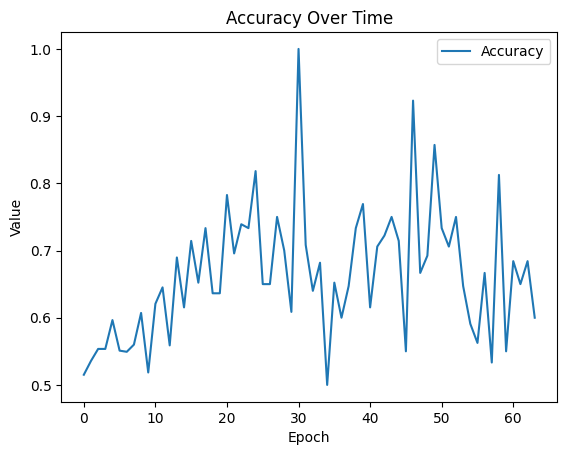

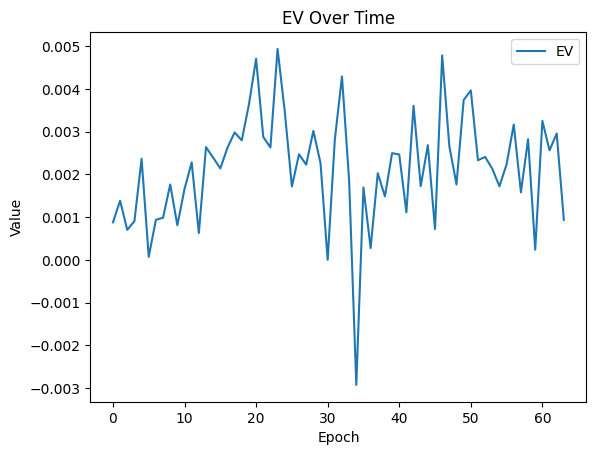

In [8]:
import json
import matplotlib.pyplot as plt

accs = []
evs = []
prompt1 = ''
prompt2 = ''
for i in range(64):
    print(f"Run count: {i+1}")
    outpath = "out_mutate_tx/full_cot/" + str(i+1) + ".json"
    # with open(outpath, 'r') as f:
    #     data = json.load(f)
    #     prompt2 = data["init_prompt"]
    # if prompt1 != prompt2:
    #     prompt1 = prompt2
    acc, ev = eval(outpath)
    #     if acc < 0.9:
    accs.append(acc)
    evs.append(ev)
    
    # if  acc > 0.75:
    #     print("============ prompt ==========")
    #     with open(outpath, 'r') as f:
    #         data = json.load(f)
    #         print(data["mutate_prompt"])
    #     print("==============================")
    #     print()

plt.plot(accs, label='Accuracy')

plt.title('Accuracy Over Time')  # 添加標題
plt.xlabel('Epoch')  # X軸標籤
plt.ylabel('Value')  # Y軸標籤
plt.legend()  # 顯示圖例

plt.show()


plt.plot(evs, label='EV')
plt.title('EV Over Time')  # 添加標題
plt.xlabel('Epoch')  # X軸標籤
plt.ylabel('Value')  # Y軸標籤
plt.legend()  # 顯示圖例

plt.show()

In [61]:
input_token = 0
output_token = 0
for i in range(42):
    with open(f"out_mutate_tx/full_cot/{i+1}.json", 'r') as f:
        data = json.load(f)
        output_data = data["output_data"]

        for date_str, result in output_data.items():
            input_token += result["token"]["input_tokens"]
            output_token += result["token"]["output_tokens"]
        # print(input_token, output_token)

print(f'token: input {input_token}, output {output_token}')
print(f'預估費用 {(input_token/1000000)*0.35 + (output_token/1000000)*0.7} USD, {((input_token/1000000)*0.35 + (output_token/1000000)*0.7)*32.6} TWD')

token: input 4936420, output 22498
預估費用 1.7434956 USD, 56.83795656 TWD


# 舊版的讀取方式

In [ ]:
# 上市公司股票代號
# 代號 ['2308', '2317', '2330', '2382', '2412', '2454', '2881', '2882', '2891', '6505']

from datetime import datetime

start_day = datetime(2023, 6, 1)
end_day = datetime(2024, 5, 30)

stock_ids = ['2308', '2317', '2330', '2382', '2412', '2454', '2881', '2882', '2891', '6505']
init_acc = 0.47
bad_acc = 1

init_prompt = """
## 企業創新舉措的影響評估：目標客群、投資者預期與股價走勢\n\n**1. 企業創新舉措分析：**\n\n* 闡述企業的創新舉措，包括其核心內容、技術應用和市場定位。\n* 分析創新舉措對目標客群的潛在影響，例如：\n    * 提升產品/服務的吸引力、功能性或價格競爭力\n    * 開拓新的市場或客群\n    * 提高客戶忠誠度或滿意度\n    * 創造新的商業模式\n\n**2. 投資者預期分析：**\n\n* 評估投資者對創新舉措的未來增長預期，包括：\n    * 營收增長\n    * 利潤率提升\n    * 市佔率擴張\n    * 新市場進入\n* 分析投資者預期與創新舉措之間的關係，例如：\n    * 投資者是否認為創新舉措能有效實現增長目標\n    * 投資者對創新舉措的風險和風險承受能力\n    * 投資者對競爭環境的預期\n\n**3. 股價走勢分析：**\n\n* 評估投資者預期對股價的影響，例如：\n    * 投資者對創新舉措的樂觀預期是否會推動股價上漲\n    * 股價上漲是否能持續，以及持續時間\n    * 影響股價波動的因素，例如：\n        * 市場整體情緒\n        * 行業發展趨勢\n        * 競爭對手的動態\n\n**4. 關鍵因素分析：**\n\n* 探究支撑投資者樂觀預期的關鍵因素，例如：\n    * 創新舉措的獨特性和競爭優勢\n    * 企業的執行能力和市場推廣策略\n    * 行業發展趨勢和政策支持\n* 分析這些關鍵因素對股價走勢的影響，以及潛在的風險和挑戰。
"""
good_prompt = """"""
bad_prompt = """"""

mutate_prompt = step2(init_prompt)
good_prompt = init_prompt

for i in range(6):
    print(f"iterate {i+1} start")
    outpath = step1(stock_ids, start_day, end_day, init_prompt, mutate_prompt)
    acc = eval(outpath)

    if acc > init_acc:
        init_acc = acc
        init_prompt = mutate_prompt
        good_prompt = mutate_prompt
        print(f"!!!!!!!!!!update prompt!!!!!!!!!!")
        print(f"init prompt: {init_prompt}")
    if acc < bad_acc:
        bad_acc = acc
        bad_prompt = mutate_prompt
    print(f"iterate {i+1} step1 done")

    # # 比較最好的兩個prompt
    # if i % 5 == 0 and i > 0:
    #     init_prompt = step3(good_prompt, bad_prompt)
    #     print(f"init prompt: {init_prompt}")
    #     print(f"iterate {i+1} step3 done")
    #     continue

    mutate_prompt = step2(init_prompt)
    print(f"iterate {i+1} step2 done")
    print()

In [6]:
#計算準確率
import pandas as pd
import json
import os

path_price_his = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/twii_history.csv"
df_price_his = pd.read_csv(path_price_his)
df_price_his['日期'] = pd.to_datetime(df_price_his['日期'], format='%Y%m%d')
token_input = 0
token_output = 0

for i in range(2, 13):
    # 計算準確率和平均報酬率
    gain = []
    loss = []

    tp = 0
    fp = 0
    tn = 0
    fn = 0

    out_path = "out_mutate2/thought mutate/" + str(i+1) + "/"
    files = os.listdir(out_path)
    files = sorted(files)

    for idx, file in enumerate(files):
        # print(file)
        with open(out_path + file, "r", encoding='utf-8') as f:
            data = json.load(f)
            token_input += data["token"]["input_tokens"]
            token_output += data["token"]["output_tokens"]
            sig_str = data["raw_data"]
            sig = 0
            if sig_str.find("unknown") > 0:
                sig = 0
            elif sig_str.find("yes") > 0:
                sig = 1
            elif sig_str.find("no")>0:
                sig = -1
            else:
                sig = 0
            # print(sig, sig_str)

        if idx+1 == len(files):
            break
        
        # print(files[idx+1])

        date_str = (files[idx+1].split(".")[0]).split("out")[1]
        df_price = df_price_his[df_price_his['日期'] == date_str]

        rtn = (df_price.iloc[0]['收盤指數'] - df_price.iloc[0]['開盤指數']) / df_price.iloc[0]['開盤指數']

        if pd.isna(rtn):
            rtn = 0

        if sig > 0:
            if rtn > 0:
                tp += 1
                gain.append(rtn)
            else:
                fp += 1
                loss.append(rtn)
        elif sig == -1: 
            if rtn < 0:
                tn += 1
                gain.append(-rtn)
            else:
                fn += 1
                loss.append(-rtn)

    print(i+1)
    # print(max_gain, max_loss, tp+fp+tn+fn)
    print(f'tp {tp}, fp {fp}, tn {tn}, fn {fn}')
    if tp + fp + tn + fn == 0:
        accuracy = 0
        print(f'Accuracy:{accuracy}')
    else:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        print(f'Accuracy:{accuracy}, Expected value:{(sum(gain) / len(gain))*accuracy + (sum(loss) / len(loss))*(1-accuracy)}')
        print(f'Average gain: {sum(gain) / len(gain)}, Average loss: {sum(loss) / len(loss)}')
    print(f'詢問次數 {len(files)}')
    print()
    # print(tn+tp+fn+fp)
print("--------------------")
print(f'token: input {token_input}, output {token_output}')
print(f'累計預估費用 {(token_input/1000000)*0.35 + (token_output/1000000)*1.05} USD, {((token_input/1000000)*0.35 + (token_output/1000000)*1.05)*32.6} TWD')


3
tp 21, fp 9, tn 0, fn 1
Accuracy:0.6774193548387096, Expected value:0.0025381579994532485
Average gain: 0.006435970265500587, Average loss: -0.005647247759246162
詢問次數 242

4
tp 34, fp 27, tn 0, fn 1
Accuracy:0.5483870967741935, Expected value:0.0008238395556456704
Average gain: 0.006205189850265603, Average loss: -0.005710657230678533
詢問次數 242

5
tp 25, fp 19, tn 1, fn 1
Accuracy:0.5652173913043478, Expected value:0.0013892201740035835
Average gain: 0.005623343222122274, Average loss: -0.004115139788550714
詢問次數 242

6
tp 15, fp 23, tn 2, fn 3
Accuracy:0.3953488372093023, Expected value:-0.0010833765945694623
Average gain: 0.006215118351917076, Average loss: -0.005855469444195276
詢問次數 242

7
tp 37, fp 34, tn 1, fn 2
Accuracy:0.5135135135135135, Expected value:0.00017317654907569218
Average gain: 0.005261349678597716, Average loss: -0.005197672865419776
詢問次數 242

8
tp 12, fp 12, tn 0, fn 0
Accuracy:0.5, Expected value:0.00031778026004219235
Average gain: 0.005428817405851622, Average l